In [ ]:
# 1. Clone the repository
!git clone https://github.com/felipevalencla/beyond-qualifying-position-formula-one.git

# 2. Read the files from the local directory
import pandas as pd

df_qualifying = pd.read_parquet('beyond-qualifying-position-formula-one/qualifying_results.parquet')
df_race = pd.read_parquet('beyond-qualifying-position-formula-one/race_results.parquet')

fatal: destination path 'beyond-qualifying-position-formula-one' already exists and is not an empty directory.


In [ ]:
print(df_race.shape)
print(df_qualifying.shape)

(3458, 10)
(3455, 12)


### Merging `df_qualifying` and `df_race`

To join the two datasets, we first need to identify the common columns. Let's inspect the column names of both DataFrames.

In [ ]:
print('Columns in df_qualifying:', df_qualifying.columns)
print('\nColumns in df_race:', df_race.columns)

Columns in df_qualifying: Index(['season', 'round', 'event_name', 'location', 'event_date',
       'event_format', 'DriverId', 'TeamId', 'qualifying_position', 'Q1', 'Q2',
       'Q3'],
      dtype='object')

Columns in df_race: Index(['season', 'round', 'DriverId', 'TeamId', 'grid_position',
       'race_finishing_position', 'classified_position', 'status',
       'raw_points', 'laps_completed'],
      dtype='object')


Based on the column names, 'season', 'round', and 'DriverId' appear to be common keys. We will perform a left merge from `df_race` to include qualifying information, as each race result corresponds to a qualifying session.

In [ ]:
# Merge the two dataframes
df_merged = pd.merge(df_qualifying, df_race, on=['season', 'round', 'DriverId', 'TeamId'], how='outer')

print(df_merged.shape)

# Display the first 5 rows of the merged dataframe
display(df_merged.head())

(3459, 18)


,season,round,event_name,location,event_date,event_format,DriverId,TeamId,qualifying_position,Q1,Q2,Q3,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed
0,2018,1,Australian Grand Prix,Melbourne,2018-03-25,conventional,alonso,mclaren,11,0 days 00:01:23.597000,0 days 00:01:23.692000,NaT,10,5,5,Finished,10.0,58
1,2018,1,Australian Grand Prix,Melbourne,2018-03-25,conventional,bottas,mercedes,10,0 days 00:01:23.686000,0 days 00:01:22.089000,NaT,15,8,8,Finished,4.0,58
2,2018,1,Australian Grand Prix,Melbourne,2018-03-25,conventional,brendon_hartley,toro_rosso,16,0 days 00:01:24.532000,NaT,NaT,16,15,15,+1 Lap,0.0,57
3,2018,1,Australian Grand Prix,Melbourne,2018-03-25,conventional,ericsson,sauber,17,0 days 00:01:24.556000,NaT,NaT,17,19,R,Steering,0.0,5
4,2018,1,Australian Grand Prix,Melbourne,2018-03-25,conventional,gasly,toro_rosso,20,0 days 00:01:25.295000,NaT,NaT,20,18,R,Engine,0.0,13


### Identifying Missing Values in `df_merged`

Let's check for any missing values in the newly merged DataFrame to understand its completeness.

In [ ]:
# Calculate the number of missing values per column
missing_values = df_merged.isnull().sum()

# Filter and display columns with missing values, sorted in descending order
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_values.empty:
    print("Columns with missing values in df_merged:")
    display(missing_values)
else:
    print("No missing values found in df_merged.")

Columns with missing values in df_merged:


,0
Q3,1771
Q2,911
Q1,47
event_date,4
location,4
event_name,4
qualifying_position,4
event_format,4
grid_position,1
race_finishing_position,1


In [ ]:
unmerged_rows = df_merged[df_merged['qualifying_position'].isnull()]

print(f"Number of rows from df_race that did not merge with df_qualifying: {unmerged_rows.shape[0]}")
display(unmerged_rows.head())

Number of rows from df_race that did not merge with df_qualifying: 4


,season,round,event_name,location,event_date,event_format,DriverId,TeamId,qualifying_position,Q1,Q2,Q3,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed
460,2019,3,NaN,NaN,NaT,NaN,albon,toro_rosso,<NA>,NaT,NaT,NaT,0,10,10,+1 Lap,1.0,55
463,2019,3,NaN,NaN,NaT,NaN,giovinazzi,alfa,<NA>,NaT,NaT,NaT,19,15,15,+1 Lap,0.0,55
1269,2021,5,NaN,NaN,NaT,NaN,mick_schumacher,haas,<NA>,NaT,NaT,NaT,20,18,18,+3 Laps,0.0,75
3383,2025,21,NaN,NaN,NaT,NaN,bortoleto,sauber,<NA>,NaT,NaT,NaT,18,20,R,Retired,0.0,0


In [ ]:
rounds_per_driver_season = df_merged.groupby(['DriverId', 'season'])['round'].nunique().reset_index()
rounds_per_driver_season = rounds_per_driver_season.rename(columns={'round': 'number_of_races'})
display(rounds_per_driver_season.tail())

,DriverId,season,number_of_races
168,vettel,2021,22
169,vettel,2022,20
170,zhou,2022,22
171,zhou,2023,22
172,zhou,2024,24


In [ ]:
end_year = 2025

for start_year in range(2018, end_year + 1):
    print(f"\n--- Drivers active in all seasons from {start_year} to {end_year} ---")
    current_total_seasons_in_range = end_year - start_year + 1

    # Filter for the current season range
    current_season_filtered_drivers = rounds_per_driver_season[
        (rounds_per_driver_season['season'] >= start_year) &
        (rounds_per_driver_season['season'] <= end_year)
    ]

    # Group by DriverId and count unique seasons in the current range
    current_drivers_in_all_seasons = current_season_filtered_drivers.groupby('DriverId')['season'].nunique().reset_index()

    # Filter for drivers who have been in all seasons within the current range
    current_drivers_in_all_seasons = current_drivers_in_all_seasons[
        current_drivers_in_all_seasons['season'] == current_total_seasons_in_range
    ]

    if not current_drivers_in_all_seasons.empty:
        display(current_drivers_in_all_seasons['DriverId'].unique())
    else:
        print("No drivers found for this range.")


--- Drivers active in all seasons from 2018 to 2025 ---


<StringArray>
['gasly', 'hamilton', 'leclerc', 'max_verstappen', 'sainz', 'stroll']
Length: 6, dtype: string


--- Drivers active in all seasons from 2019 to 2025 ---


<StringArray>
[         'gasly',       'hamilton',        'leclerc', 'max_verstappen',
         'norris',        'russell',          'sainz',         'stroll']
Length: 8, dtype: string


--- Drivers active in all seasons from 2020 to 2025 ---


...

<StringArray>
[         'albon',         'alonso',          'gasly',       'hamilton',
     'hulkenberg',         'lawson',        'leclerc', 'max_verstappen',
         'norris',           'ocon',        'piastri',        'russell',
          'sainz',         'stroll',        'tsunoda']
Length: 15, dtype: string


--- Drivers active in all seasons from 2024 to 2025 ---


<StringArray>
[         'albon',         'alonso',        'bearman',      'colapinto',
         'doohan',          'gasly',       'hamilton',     'hulkenberg',
         'lawson',        'leclerc', 'max_verstappen',         'norris',
           'ocon',        'piastri',        'russell',          'sainz',
         'stroll',        'tsunoda']
Length: 18, dtype: string


--- Drivers active in all seasons from 2025 to 2025 ---


<StringArray>
[         'albon',         'alonso',      'antonelli',        'bearman',
      'bortoleto',      'colapinto',         'doohan',          'gasly',
         'hadjar',       'hamilton',     'hulkenberg',         'lawson',
        'leclerc', 'max_verstappen',         'norris',           'ocon',
        'piastri',        'russell',          'sainz',         'stroll',
        'tsunoda']
Length: 21, dtype: string

In [ ]:
df_merged['status'].unique()

<StringArray>
[        'Finished',           '+1 Lap',         'Steering',
           'Engine',            'Wheel',           'Brakes',
         'Puncture',       'Electrical', 'Collision damage',
         'Accident',        'Collision',          '+2 Laps',
         'Oil leak',            'Turbo',          '+3 Laps',
          'Gearbox',          'Exhaust',       'Hydraulics',
    'Fuel pressure',       'Power Unit',             'Tyre',
          'Retired',       'Suspension',       'Power loss',
     'Disqualified',       'Mechanical',          'Battery',
      'Overheating',           'Damage',      'Out of fuel',
     'Transmission',         'Spun off',   'Water pressure',
         'Withdrew',      'Electronics',          '+5 Laps',
           'Debris',         'Radiator',          'Illness',
        'Wheel nut',       'Driveshaft',        'Rear wing',
       'Water pump',   'Cooling system',        'Fuel leak',
       'Front wing',       'Water leak',       'Vibrations',
        'F

### IncidentDNF includes:

- Accident: Directly implies a driving-related mishap.
- Collision & Collision Damage: Similar to 'Accident', indicates impact due to driving & inability to continue.
- Spun off: A clear driving error.

In [ ]:
did_not_start_drivers = df_merged[df_merged['status'] == 'Did not start'][['DriverId', 'season']].drop_duplicates()
display(did_not_start_drivers)

,DriverId,season
2338,tsunoda,2023
2395,sainz,2023
2447,leclerc,2023
2722,gasly,2024
2899,albon,2024
2916,stroll,2024
3196,sainz,2025
3204,colapinto,2025
3288,hulkenberg,2025


In [ ]:
df_merged['grid_equals_qualifying'] = (df_merged['grid_position'] == df_merged['qualifying_position'])

# Display rows where grid_position is NOT equal to qualifying_position
falses_df = df_merged[df_merged['grid_equals_qualifying'] == False]
display(falses_df[['DriverId', 'season', 'round', 'qualifying_position', 'grid_position']])

,DriverId,season,round,qualifying_position,grid_position
0,alonso,2018,1,11,10
1,bottas,2018,1,10,15
5,grosjean,2018,1,7,6
7,hulkenberg,2018,1,8,7
8,kevin_magnussen,2018,1,6,5
...,...,...,...,...,...
3423,bortoleto,2025,23,14,19
3427,hamilton,2025,23,18,17
3433,ocon,2025,23,17,16
3437,stroll,2025,23,19,18


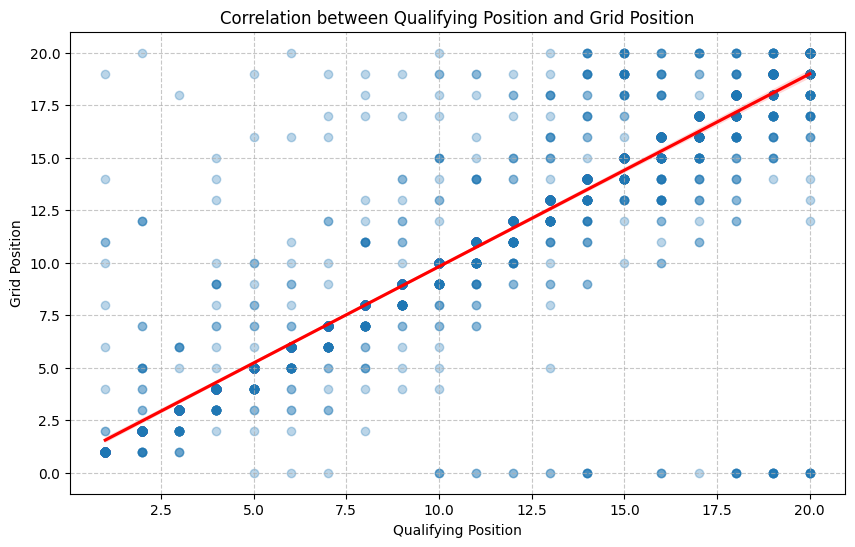

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(data=df_merged, x='qualifying_position', y='grid_position', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation between Qualifying Position and Grid Position')
plt.xlabel('Qualifying Position')
plt.ylabel('Grid Position')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## `grid_position` must be removed because we want to predict from the results on Saturday what will happen in the race results.

In [ ]:
df_merged['event_format'].unique()

array(['conventional', nan, 'sprint', 'sprint_shootout',
       'sprint_qualifying'], dtype=object)

## `conventional` is the only one to filter on, the others shouldn't be included.